In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 10)

print("=" * 60)
print("LOADING DATASETS")
print("=" * 60)

# Check current working directory
print(f"Current working directory: {os.getcwd()}")

# Load the datasets - use '../' to go up one level from notebooks folder
unemployment = pd.read_csv('../data/raw/south_africa_unemployment.csv')
education = pd.read_csv('../data/raw/south_africa_tertiary_education.csv')

print(f"Unemployment shape: {unemployment.shape}")
print(f"Education shape: {education.shape}")
print(f"\nUnemployment columns: {unemployment.columns.tolist()}")
print(f"Education columns: {education.columns.tolist()}")

LOADING DATASETS
Current working directory: c:\Users\Admin\Documents\SouthAfrica-Data-Analysis\notebooks
Unemployment shape: (66, 4)
Education shape: (66, 4)

Unemployment columns: ['Country', 'Country_Code', 'Year', 'Value']
Education columns: ['Country', 'Country_Code', 'Year', 'Value']


In [3]:
print("=" * 60)
print("UNEMPLOYMENT DATASET EXPLORATION")
print("=" * 60)

print("\nFirst 10 rows:")
print(unemployment.head(10))

print("\nLast 10 rows:")
print(unemployment.tail(10))

print("\nData types:")
print(unemployment.dtypes)

print("\nSummary statistics:")
print(unemployment.describe())

print(f"\nMissing values:\n{unemployment.isna().sum()}")
print(f"Percentage missing: {unemployment['Value'].isna().mean() * 100:.1f}%")

UNEMPLOYMENT DATASET EXPLORATION

First 10 rows:
        Country Country_Code  Year  Value
0  South Africa          ZAF  1960    NaN
1  South Africa          ZAF  1961    NaN
2  South Africa          ZAF  1962    NaN
3  South Africa          ZAF  1963    NaN
4  South Africa          ZAF  1964    NaN
5  South Africa          ZAF  1965    NaN
6  South Africa          ZAF  1966    NaN
7  South Africa          ZAF  1967    NaN
8  South Africa          ZAF  1968    NaN
9  South Africa          ZAF  1969    NaN

Last 10 rows:
         Country Country_Code  Year   Value
56  South Africa          ZAF  2016  26.536
57  South Africa          ZAF  2017  27.035
58  South Africa          ZAF  2018  26.906
59  South Africa          ZAF  2019  28.468
60  South Africa          ZAF  2020  29.217
61  South Africa          ZAF  2021  34.007
62  South Africa          ZAF  2022  33.268
63  South Africa          ZAF  2023  32.098
64  South Africa          ZAF  2024  32.279
65  South Africa          ZAF  202

In [4]:
print("=" * 60)
print("EDUCATION DATASET EXPLORATION")
print("=" * 60)

print("\nFirst 10 rows:")
print(education.head(10))

print("\nLast 10 rows:")
print(education.tail(10))

print("\nData types:")
print(education.dtypes)

print("\nSummary statistics:")
print(education.describe())

print(f"\nMissing values:\n{education.isna().sum()}")
print(f"Percentage missing: {education['Value'].isna().mean() * 100:.1f}%")

EDUCATION DATASET EXPLORATION

First 10 rows:
        Country Country_Code  Year  Value
0  South Africa          ZAF  1960    NaN
1  South Africa          ZAF  1961    NaN
2  South Africa          ZAF  1962    NaN
3  South Africa          ZAF  1963    NaN
4  South Africa          ZAF  1964    NaN
5  South Africa          ZAF  1965    NaN
6  South Africa          ZAF  1966    NaN
7  South Africa          ZAF  1967    NaN
8  South Africa          ZAF  1968    NaN
9  South Africa          ZAF  1969    NaN

Last 10 rows:
         Country Country_Code  Year      Value
56  South Africa          ZAF  2016  18.929298
57  South Africa          ZAF  2017  21.090291
58  South Africa          ZAF  2018  22.351543
59  South Africa          ZAF  2019  22.244247
60  South Africa          ZAF  2020  22.614874
61  South Africa          ZAF  2021  22.343129
62  South Africa          ZAF  2022  23.727104
63  South Africa          ZAF  2023  23.493769
64  South Africa          ZAF  2024        NaN
65  Sou

In [5]:
print("=" * 60)
print("VALID DATA RANGES")
print("=" * 60)

# Filter to valid (non-null) data
unemployment_valid = unemployment.dropna(subset=['Value'])
education_valid = education.dropna(subset=['Value'])

print(f"\nUNEMPLOYMENT:")
print(f"  Valid years: {unemployment_valid['Year'].min()} - {unemployment_valid['Year'].max()}")
print(f"  Number of valid observations: {len(unemployment_valid)}")
print(f"  First 5 valid records:")
print(unemployment_valid.head(5))
print(f"  Last 5 valid records:")
print(unemployment_valid.tail(5))

print(f"\nEDUCATION:")
print(f"  Valid years: {education_valid['Year'].min()} - {education_valid['Year'].max()}")
print(f"  Number of valid observations: {len(education_valid)}")
print(f"  First 5 valid records:")
print(education_valid.head(5))
print(f"  Last 5 valid records:")
print(education_valid.tail(5))

VALID DATA RANGES

UNEMPLOYMENT:
  Valid years: 1991 - 2025
  Number of valid observations: 35
  First 5 valid records:
         Country Country_Code  Year   Value
31  South Africa          ZAF  1991  23.137
32  South Africa          ZAF  1992  23.463
33  South Africa          ZAF  1993  23.361
34  South Africa          ZAF  1994  23.067
35  South Africa          ZAF  1995  22.705
  Last 5 valid records:
         Country Country_Code  Year   Value
61  South Africa          ZAF  2021  34.007
62  South Africa          ZAF  2022  33.268
63  South Africa          ZAF  2023  32.098
64  South Africa          ZAF  2024  32.279
65  South Africa          ZAF  2025  32.391

EDUCATION:
  Valid years: 1970 - 2023
  Number of valid observations: 21
  First 5 valid records:
         Country Country_Code  Year     Value
10  South Africa          ZAF  1970   3.98838
13  South Africa          ZAF  1973   4.39185
28  South Africa          ZAF  1988  10.52101
29  South Africa          ZAF  1989  11.32593

In [6]:
print("=" * 60)
print("COMMON YEARS ANALYSIS")
print("=" * 60)

# Find common years
common_years = set(unemployment_valid['Year']) & set(education_valid['Year'])
common_years_sorted = sorted(common_years)

print(f"\nNumber of common years: {len(common_years)}")
print(f"Common years range: {min(common_years)} - {max(common_years)}")
print(f"\nFirst 10 common years: {common_years_sorted[:10]}")
print(f"Last 10 common years: {common_years_sorted[-10:]}")

# Check continuity
expected_count = common_years_sorted[-1] - common_years_sorted[0] + 1
print(f"\nExpected years if continuous: {expected_count}")
print(f"Actual count: {len(common_years_sorted)}")
print(f"Missing years: {expected_count - len(common_years_sorted)}")

COMMON YEARS ANALYSIS

Number of common years: 16
Common years range: 1991 - 2023

First 10 common years: [1991, 1992, 1993, 1994, 2012, 2013, 2014, 2015, 2016, 2017]
Last 10 common years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

Expected years if continuous: 33
Actual count: 16
Missing years: 17


VISUALIZING THE DATA


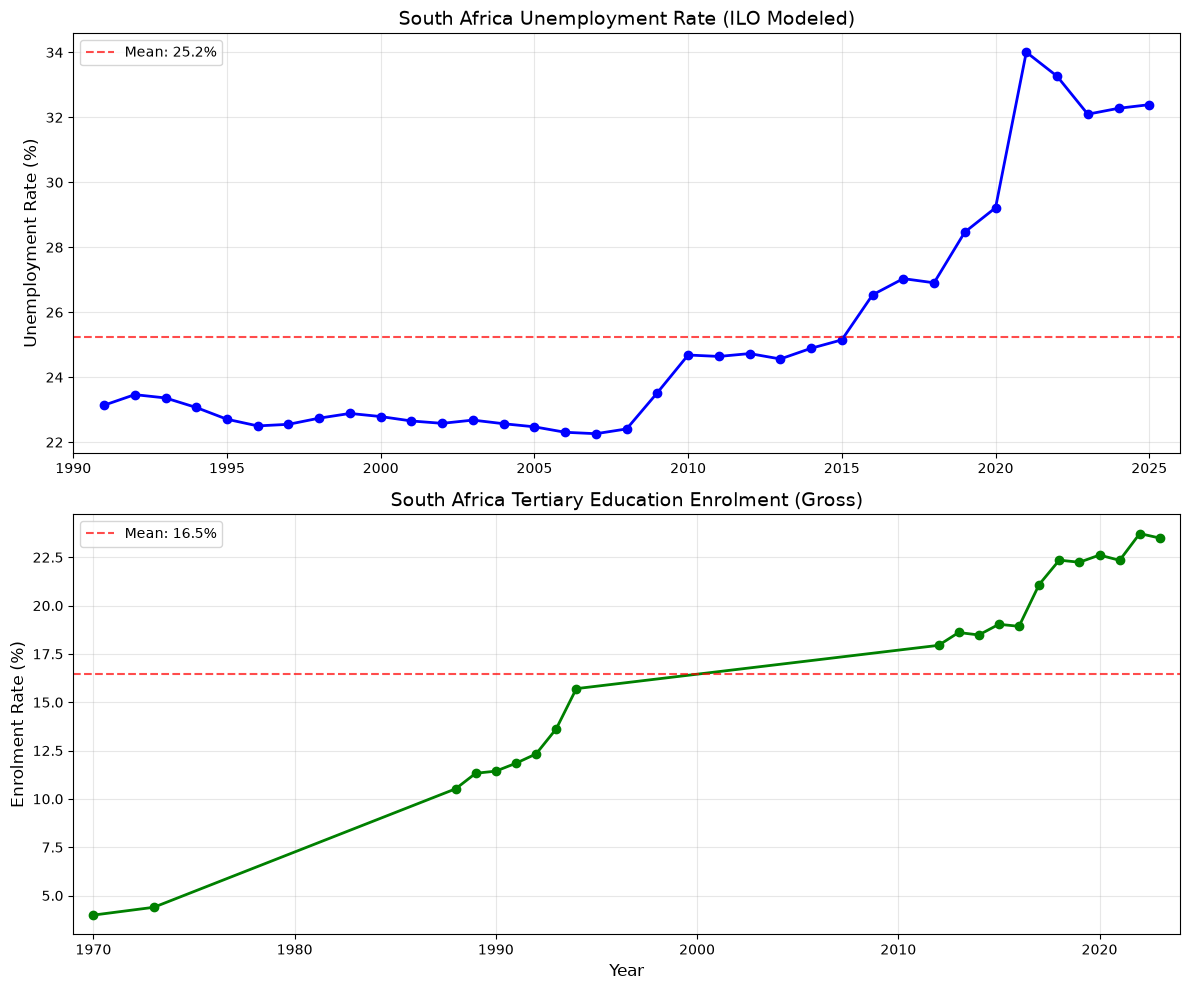

In [7]:
print("=" * 60)
print("VISUALIZING THE DATA")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Unemployment plot
axes[0].plot(unemployment_valid['Year'], unemployment_valid['Value'], 
             'b-o', linewidth=2, markersize=6)
axes[0].set_title('South Africa Unemployment Rate (ILO Modeled)', fontsize=14)
axes[0].set_ylabel('Unemployment Rate (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=unemployment_valid['Value'].mean(), color='r', linestyle='--', 
                alpha=0.7, label=f'Mean: {unemployment_valid["Value"].mean():.1f}%')
axes[0].legend()
axes[0].set_xlim(unemployment_valid['Year'].min() - 1, unemployment_valid['Year'].max() + 1)

# Education plot
axes[1].plot(education_valid['Year'], education_valid['Value'], 
             'g-o', linewidth=2, markersize=6)
axes[1].set_title('South Africa Tertiary Education Enrolment (Gross)', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Enrolment Rate (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=education_valid['Value'].mean(), color='r', linestyle='--', 
                alpha=0.7, label=f'Mean: {education_valid["Value"].mean():.1f}%')
axes[1].legend()
axes[1].set_xlim(education_valid['Year'].min() - 1, education_valid['Year'].max() + 1)

plt.tight_layout()
plt.show()

In [8]:
print("=" * 60)
print("PREPARING FOR MERGE")
print("=" * 60)

# Rename columns for clarity
unemployment_clean = unemployment_valid.copy()
education_clean = education_valid.copy()

unemployment_clean = unemployment_clean.rename(columns={'Value': 'Unemployment_Rate'})
education_clean = education_clean.rename(columns={'Value': 'Tertiary_Enrolment'})

# Keep only needed columns
unemployment_clean = unemployment_clean[['Year', 'Unemployment_Rate']]
education_clean = education_clean[['Year', 'Tertiary_Enrolment']]

print(f"Unemployment prepared shape: {unemployment_clean.shape}")
print(f"Education prepared shape: {education_clean.shape}")

# Merge on Year (inner join keeps only common years)
merged_df = pd.merge(unemployment_clean, education_clean, on='Year', how='inner')

print(f"\nMerged dataset shape: {merged_df.shape}")
print(f"\nMerged dataset - first 10 rows:")
print(merged_df.head(10))
print(f"\nMerged dataset - last 10 rows:")
print(merged_df.tail(10))

print(f"\nMerged dataset statistics:")
print(merged_df.describe())

# Check correlation
correlation = merged_df['Unemployment_Rate'].corr(merged_df['Tertiary_Enrolment'])
print(f"\nCorrelation between Unemployment and Tertiary Enrolment: {correlation:.3f}")

PREPARING FOR MERGE
Unemployment prepared shape: (35, 2)
Education prepared shape: (21, 2)

Merged dataset shape: (16, 3)

Merged dataset - first 10 rows:
   Year  Unemployment_Rate  Tertiary_Enrolment
0  1991             23.137           11.845070
1  1992             23.463           12.327320
2  1993             23.361           13.623300
3  1994             23.067           15.704500
4  2012             24.727           17.944723
5  2013             24.561           18.608823
6  2014             24.890           18.481336
7  2015             25.149           19.033295
8  2016             26.536           18.929298
9  2017             27.035           21.090291

Merged dataset - last 10 rows:
    Year  Unemployment_Rate  Tertiary_Enrolment
6   2014             24.890           18.481336
7   2015             25.149           19.033295
8   2016             26.536           18.929298
9   2017             27.035           21.090291
10  2018             26.906           22.351543
11  2019

In [9]:
# Make sure processed folder exists
os.makedirs('../data/processed', exist_ok=True)

# Save the merged dataset
merged_df.to_csv('../data/processed/south_africa_combined.csv', index=False)
print("✅ Saved combined dataset to: data/processed/south_africa_combined.csv")
print(f"   Shape: {merged_df.shape}")
print(f"   Years: {merged_df['Year'].min()} - {merged_df['Year'].max()}")

✅ Saved combined dataset to: data/processed/south_africa_combined.csv
   Shape: (16, 3)
   Years: 1991 - 2023


In [2]:
import sqlite3
import pandas as pd
from pathlib import Path

# Go up one level from notebooks folder to project root
db_path = Path('..') / 'database' / 'south_africa_data.db'
conn = sqlite3.connect(db_path)

# Query example
df = pd.read_sql_query("SELECT * FROM south_africa_data", conn)
print(df)

conn.close()

    id  year  unemployment_rate  tertiary_enrolment           created_at
0    1  1991             23.137           11.845070  2026-08-28 19:05:46
1    2  1992             23.463           12.327320  2026-08-28 19:05:46
2    3  1993             23.361           13.623300  2026-08-28 19:05:46
3    4  1994             23.067           15.704500  2026-08-28 19:05:46
4    5  2012             24.727           17.944723  2026-08-28 19:05:46
5    6  2013             24.561           18.608823  2026-08-28 19:05:46
6    7  2014             24.890           18.481336  2026-08-28 19:05:46
7    8  2015             25.149           19.033295  2026-08-28 19:05:46
8    9  2016             26.536           18.929298  2026-08-28 19:05:46
9   10  2017             27.035           21.090291  2026-08-28 19:05:46
10  11  2018             26.906           22.351543  2026-08-28 19:05:46
11  12  2019             28.468           22.244247  2026-08-28 19:05:46
12  13  2020             29.217           22.614874

In [3]:
from pathlib import Path

# Check if database file exists
db_path = Path('..') / 'database' / 'south_africa_data.db'
print(f"Database exists: {db_path.exists()}")
print(f"Database path: {db_path.absolute()}")

Database exists: True
Database path: c:\Users\Admin\Documents\SouthAfrica-Data-Analysis\notebooks\..\database\south_africa_data.db


In [4]:
import sqlite3
import pandas as pd
from pathlib import Path

# Connect to database
db_path = Path('..') / 'database' / 'south_africa_data.db'
conn = sqlite3.connect(db_path)

# 1. Get all data
print("=" * 60)
print("ALL DATA")
print("=" * 60)
df = pd.read_sql_query("SELECT * FROM south_africa_data ORDER BY year", conn)
print(df)

# 2. Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
summary = pd.read_sql_query("""
    SELECT 
        COUNT(*) as total_records,
        MIN(year) as min_year,
        MAX(year) as max_year,
        ROUND(AVG(unemployment_rate), 2) as avg_unemployment,
        ROUND(MIN(unemployment_rate), 2) as min_unemployment,
        ROUND(MAX(unemployment_rate), 2) as max_unemployment,
        ROUND(AVG(tertiary_enrolment), 2) as avg_enrolment,
        ROUND(MIN(tertiary_enrolment), 2) as min_enrolment,
        ROUND(MAX(tertiary_enrolment), 2) as max_enrolment
    FROM south_africa_data
""", conn)
print(summary)

# 3. Unemployment trend
print("\n" + "=" * 60)
print("UNEMPLOYMENT TREND")
print("=" * 60)
trend = pd.read_sql_query("""
    SELECT 
        year,
        unemployment_rate,
        tertiary_enrolment
    FROM south_africa_data 
    ORDER BY year
""", conn)
print(trend)

# 4. Recent data (2020-2023)
print("\n" + "=" * 60)
print("RECENT DATA (2020-2023)")
print("=" * 60)
recent = pd.read_sql_query("""
    SELECT * FROM south_africa_data 
    WHERE year >= 2020 
    ORDER BY year
""", conn)
print(recent)

conn.close()

ALL DATA
    id  year  unemployment_rate  tertiary_enrolment           created_at
0    1  1991             23.137           11.845070  2026-08-28 19:05:46
1    2  1992             23.463           12.327320  2026-08-28 19:05:46
2    3  1993             23.361           13.623300  2026-08-28 19:05:46
3    4  1994             23.067           15.704500  2026-08-28 19:05:46
4    5  2012             24.727           17.944723  2026-08-28 19:05:46
5    6  2013             24.561           18.608823  2026-08-28 19:05:46
6    7  2014             24.890           18.481336  2026-08-28 19:05:46
7    8  2015             25.149           19.033295  2026-08-28 19:05:46
8    9  2016             26.536           18.929298  2026-08-28 19:05:46
9   10  2017             27.035           21.090291  2026-08-28 19:05:46
10  11  2018             26.906           22.351543  2026-08-28 19:05:46
11  12  2019             28.468           22.244247  2026-08-28 19:05:46
12  13  2020             29.217           